## Dataset Statistics

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import measure
import random
import os

In [3]:
IMG_NUM = 12568

In [4]:
df = pd.read_csv("./dataset/train.csv")
print(df.head())

         ImageId  ClassId                                      EncodedPixels
0  0002cc93b.jpg        1  29102 12 29346 24 29602 24 29858 24 30114 24 3...
1  0007a71bf.jpg        3  18661 28 18863 82 19091 110 19347 110 19603 11...
2  000a4bcdd.jpg        1  37607 3 37858 8 38108 14 38359 20 38610 25 388...
3  000f6bf48.jpg        4  131973 1 132228 4 132483 6 132738 8 132993 11 ...
4  0014fce06.jpg        3  229501 11 229741 33 229981 55 230221 77 230468...


### Images with defects ratio

In [5]:
defects_num = len(df["ImageId"])
img_with_defects_num = len(set(df["ImageId"]))

print(f"Number of images with defects: {img_with_defects_num}")
print(f"Number of images without defects: {IMG_NUM - img_with_defects_num}")
print(f"Average number of defects of different type per image (with defects): {defects_num / img_with_defects_num}")

Number of images with defects: 6666
Number of images without defects: 5902
Average number of defects of different type per image (with defects): 1.0643564356435644


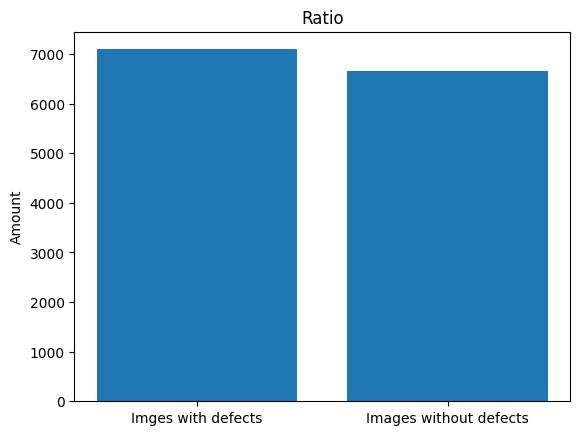

In [6]:
plt.bar(["Imges with defects", "Images without defects"],[defects_num, img_with_defects_num])
plt.ylabel("Amount")
plt.title("Ratio")
plt.show()

### Defects ratio

In [7]:
defects_ratio = df["ClassId"].value_counts().sort_index()
defects_ratio

ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64

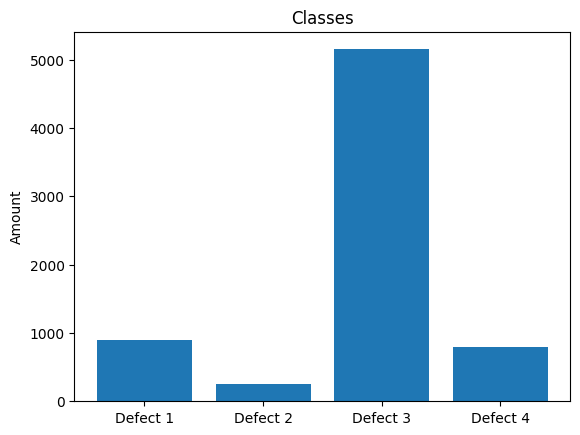

In [8]:
x_labels = ["Defect 1", "Defect 2", "Defect 3", "Defect 4"]

plt.bar(x_labels, defects_ratio)
plt.title("Classes")
plt.ylabel("Amount")
plt.show()

### Images visualization

/var/folders/2s/35w_x_5d36n8z709h467h90r0000gn/T/ipykernel_46431/4217047428.py:13: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  selected = random.sample(image_paths, 9)


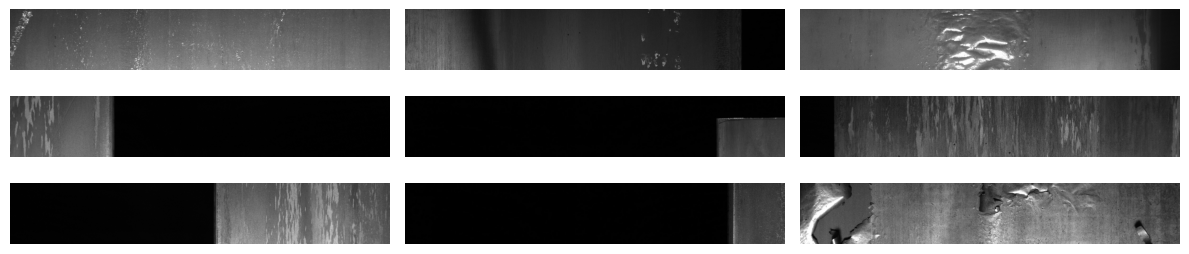

In [9]:
DEFECT = 0   # 0: no defect


if DEFECT != 0:
    filtered_df = df[df["ClassId"] == DEFECT]

else:
    all_images_list = os.listdir("./dataset/train_images")
    all_images_list = pd.DataFrame(all_images_list, columns=["ImageId"])
    filtered_df = all_images_list[~all_images_list["ImageId"].isin(df["ImageId"])]

image_paths = set(filtered_df["ImageId"])
selected = random.sample(image_paths, 9)

fig, axes = plt.subplots(3,3, figsize=(12,3))
for ax, img_path in zip(axes.flatten(), selected):
    img = Image.open(f"./dataset/train_images/{img_path}")
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Defects visualization

In [10]:
import numpy as np

def rle_to_mask(rle, shape):
    # shape = (height, width)
    height, width = shape

    rle = list(map(int, rle.split()))
    mask = np.zeros(height * width, dtype=np.uint8)

    for start, length in zip(rle[0::2], rle[1::2]):
        start -= 1
        mask[start:start+length] = 1

    return mask.reshape((height, width), order="F")


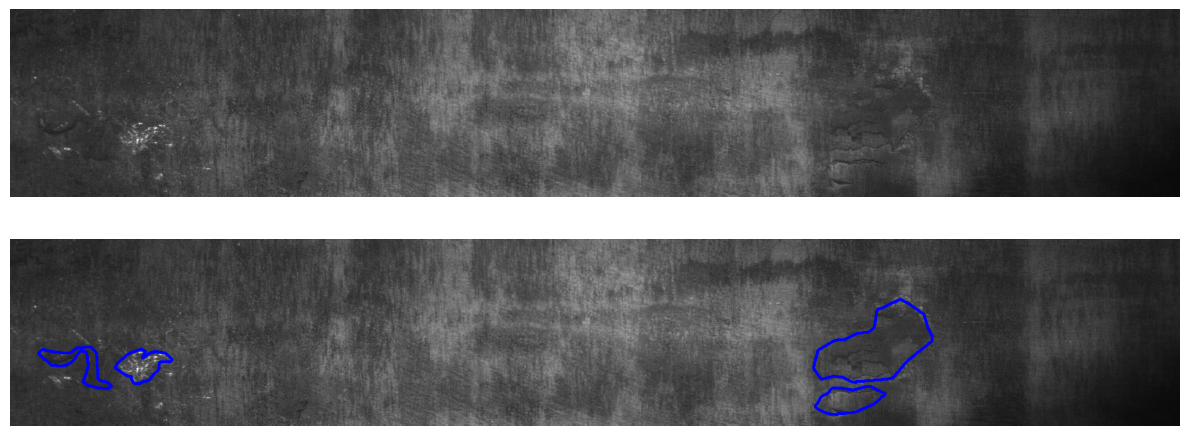

In [11]:
DEFECT = 4


if DEFECT == 1:
    contour_color = "red"
elif DEFECT == 2:
    contour_color = "aqua"
elif DEFECT == 3:
    contour_color = "yellow"
elif DEFECT == 4:
    contour_color = "blue"


filtered_df = df[df["ClassId"] == DEFECT]
sampled_row = random.randint(0, len(filtered_df) - 1)

sample = filtered_df.iloc[sampled_row]

img_name = sample["ImageId"]
img_path = f"./dataset/train_images/{img_name}"
img = np.array(Image.open(img_path))

rle_string = sample["EncodedPixels"]
mask = rle_to_mask(rle_string, img.shape[:2])

contours = measure.find_contours(mask, 0.5)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].imshow(img)
axes[0].axis("off")

axes[1].imshow(img)
axes[1].axis("off")

for contour in contours:
    axes[1].plot(contour[:, 1], contour[:, 0], linewidth=2, color=contour_color)

plt.tight_layout()
plt.show()